# Getting Started

## First STLDriver object

In [ ]:
import stlrom as stl
d = stl.STLDriver()
d.parse_string('signal x,y')
print(d)

## Adding signal data

In [ ]:
d.add_sample([0, -0.4, 0.6]) # time, x, y
d.add_sample([0.5, 0.7, 0.1])
d.add_sample([1.1, -0.1, 0.7])
print(d)

## First Plots

In [ ]:
ax = d.plot_signals(['x', 'y'])

## First Predicates

In [ ]:
d.parse_string("""
mu_x    := x[t]>0
mu_y    := y[t]>.5
mu_comp := x[t]<y[t]
""")
print(d)

## Satisfaction Evaluation

### Boolean Satisfaction

In [ ]:
d.set_semantics('BOOLEAN')
sat_mu = d.get_rob_signal('mu_x',0,1.1)
print(sat_mu)

In [ ]:
ax = d.plot_signal('x')  # plots signal x, returns axis
ax = sat_mu.plot(label='Satisfaction of x > 0', ax=ax)


### Robust Satisfaction

In [ ]:
d.set_semantics('SPACE')
rob_mu_y = d.get_rob_signal('mu_y',0,1.1)
print(rob_mu_y)

In [ ]:
ax = d.plot_signal('y')  # plots signal x, returns axis
rob_mu_y.plot(label='Robustness of y > 2', ax=ax)


In [ ]:
ax = d.plot_signal('y')
rob_mu_y.plot(label='Robustness of y > 2', plot_sat=True, ax=ax)


# Signal Generation

`stlrom.signal_gen` provides a small library of signal generators. Their generic use is as follows:

- Create a signal generator object with `sig_gen= SomeSignalGen(param1= ..., param2=..., etc)`
- Get a concrete signal defined on  `[t0, tf]` with `sig= sig_gen.get_signal(t0,tf)`. Note that `t0` and `tf` are mandatory arguments.

### Piecewise Constant Signal 

In [ ]:
from stlrom.signal_gen import PWCSignalGen

pwc_gen = PWCSignalGen(times=[0, 1., 2., 2.5, 3.],
                       values=[0., 1., -0.5, 0.8, 0.5])
pwc_signal = pwc_gen.get_signal(0,3)
pwc_signal.plot(label='PWC signal');

### Piecewise Linear Signals

In [ ]:
from stlrom import PWLSignalGen

pwl_gen = PWLSignalGen(times=[0, 1., 2., 2.5, 3.],
                       values=[0., 1., -0.5, 0.8, 0.5])
#pwl_signal = pwl_gen.get_signal(t0=0, tf=3)
pwl_signal = pwl_gen.get_signal(0,3)
pwl_signal.plot(label='PWL signal');

### Oscillation Signals

[ 0.    0.02  0.04  0.06  0.08  0.1   0.12  0.14  0.16  0.18  0.2   0.22
  0.24  0.26  0.28  0.3   0.32  0.34  0.36  0.38  0.4   0.42  0.44  0.46
  0.48  0.5   0.52  0.54  0.56  0.58  0.6   0.62  0.64  0.66  0.68  0.7
  0.72  0.74  0.76  0.78  0.8   0.82  0.84  0.86  0.88  0.9   0.92  0.94
  0.96  0.98  1.    1.02  1.04  1.06  1.08  1.1   1.12  1.14  1.16  1.18
  1.2   1.22  1.24  1.26  1.28  1.3   1.32  1.34  1.36  1.38  1.4   1.42
  1.44  1.46  1.48  1.5   1.52  1.54  1.56  1.58  1.6   1.62  1.64  1.66
  1.68  1.7   1.72  1.74  1.76  1.78  1.8   1.82  1.84  1.86  1.88  1.9
  1.92  1.94  1.96  1.98  2.    2.02  2.04  2.06  2.08  2.1   2.12  2.14
  2.16  2.18  2.2   2.22  2.24  2.26  2.28  2.3   2.32  2.34  2.36  2.38
  2.4   2.42  2.44  2.46  2.48  2.5   2.52  2.54  2.56  2.58  2.6   2.62
  2.64  2.66  2.68  2.7   2.72  2.74  2.76  2.78  2.8   2.82  2.84  2.86
  2.88  2.9   2.92  2.94  2.96  2.98  3.    3.02  3.04  3.06  3.08  3.1
  3.12  3.14  3.16  3.18  3.2   3.22  3.24  3.26  3.28

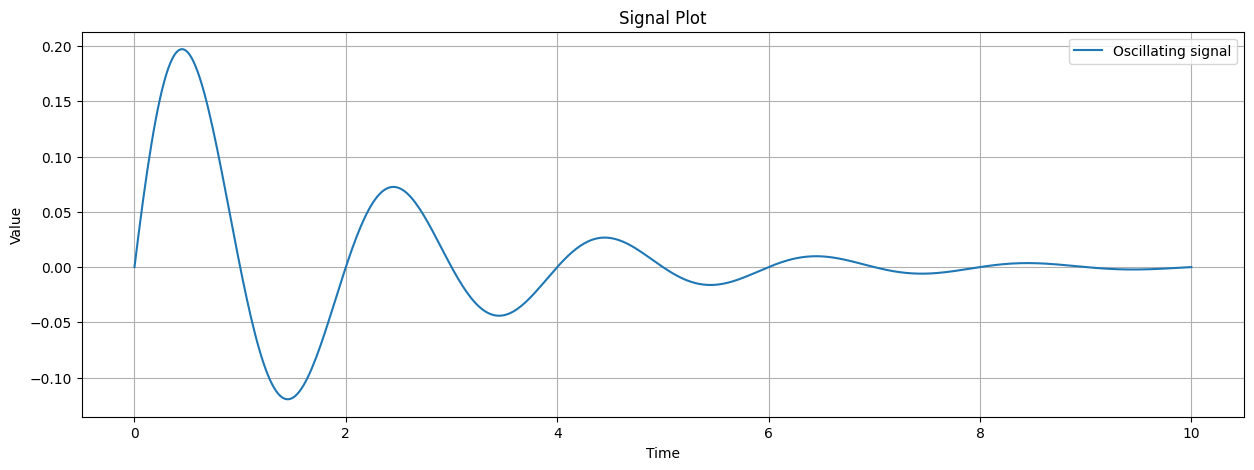

In [ ]:
from stlrom import OscillSignalGen

osc_gen = OscillSignalGen(period=2, amplitude=0.25, base=0, damp=-0.5)
x0  = osc_gen.get_signal(t0=0, tf=10, dt=0.02)
ax = x0.plot(label='Oscillating signal');

x1 = osc_gen.set_param(damp=0.1, period=1).get_signal(0,10, dt=0.02)
x1.plot(ax=ax)

# Robustness of Equality

In [ ]:
d2 = stl.STLDriver()
d2.parse_string("""
    signal x
    mu_eq := x[t] == 0
    """)

d2.set_signals([osc_signal])
print(d2)

In [ ]:
stl.Signal.set_Eps(0.01)

rob_eq = d2.get_rob_signal('mu_eq', 0, 10)

ax = osc_signal.plot(label='Oscillating signal');
ax.plot([0, osc_signal.end_time], [stl.Signal.get_Eps(), stl.Signal.get_Eps()], linestyle='--', color='black', label="± $\\varepsilon$")
ax.plot([0, osc_signal.end_time], [-stl.Signal.get_Eps(), -stl.Signal.get_Eps()], linestyle='--', color='black')
ax = rob_eq.plot(label='Robustness of mu_eq for oscillating signal', ax=ax);



In [ ]:
stl.Signal.set_Eps(1e-12)

# Temperature Example

## Generating Signal

In [ ]:
import numpy as np
times = np.linspace(0, 12, 100)
values = 18 + 9 * np.sin(times) + 3 * np.sin(3 * times)
temp_signal = PWLSignalGen(times = times, values = values).get_signal(0,12)

ax = temp_signal.plot(label='Temperature signal');
ax.plot([0, temp_signal.end_time], [25, 25], linestyle='--', color='black', label="Threshold temperature");
ax.legend();


## Parsing Formulas

In [ ]:
d3 = stl.STLDriver()
d3.parse_string("""signal temp                
    param Tmax = 25, tau=2
    mu_temp := temp[t] < Tmax

    # Temperature should always be below Tmax
    phi_ev := ev[0, tau] (mu_temp)

    # If temperature is above Tmax, it should eventually be below Tmax within 2 seconds
    phi := alw[0, 8 ] ((not mu_temp) => phi_ev)
    """)

d3.set_signals([temp_signal])

In [ ]:
print(d3)

## Robustness of Top Formula

In [ ]:
tau=1
d3.set_param('tau', tau);d3.set_param('Tmax', 20);
d3.set_semantics('SPACE')
r_phi_ev = d3.get_rob_signal('phi_ev', 0, 12-tau)

ax = temp_signal.plot(label='Temperature signal');
r_phi_ev.plot(label='Robustness of ev[0,1](T<20)', ax=ax, plot_sat=True);

## Robustness Map

In [ ]:
r_phi, _, _ = d3.get_online_rob_signal('phi', 0, 6)
rob_map = d3.get_online_robustness_map('phi')
stl.plot_rob_map_widget(rob_map)